# 가설 검증


가설 1
- H0 : gate 40의 D1 retention은 gate 30의 D1 retention이 같다.
- H1 : gate 40의 D1 retention이 gate 30의 D1 retention보다 크다.

가설 2
- H0 : gate 40의 D7 retention은 gate 30의 D7 retention이 같다.
- H1 : gate 40의 D7 retention이 gate 30의 D7 retention보다 크다.

In [1]:
import pandas as pd
import math
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

sum_gamerounds가 0인 유저는 게임 플레이를 아예 하지 않은 유저로 판단하여 제외합니다.

In [2]:
df = pd.read_csv('../data/cookie_cats.csv')
df.sample(5)

,userid,version,sum_gamerounds,retention_1,retention_7
63954,7080780,gate_40,52,True,False
47751,5297616,gate_30,411,True,True
86070,9533755,gate_30,3,False,False
49736,5516257,gate_40,3,False,False
7828,862417,gate_30,66,True,False


In [3]:
df = df[df['sum_gamerounds'] != 0]

## retention 계산
- total retention = dn cnt / d0 cnt
- retention(group) = dn_group cnt / d0_group cnt

In [4]:
# 전체 수
d0_30 = df.groupby('version')['userid'].count().loc['gate_30']
d0_40 = df.groupby('version')['userid'].count().loc['gate_40']

print(d0_30)
print(d0_40)

42763
43432


In [5]:
d1_30 = df.groupby('version')['retention_1'].sum().loc['gate_30']
d1_40 = df.groupby('version')['retention_1'].sum().loc['gate_40']
d7_30 = df.groupby('version')['retention_7'].sum().loc['gate_30']
d7_40 = df.groupby('version')['retention_7'].sum().loc['gate_40']
print(d1_30, d1_40, d7_30, d7_40)

19993 20073 8486 8266


In [6]:
r_d1_30 = df[df.version == 'gate_30']['retention_1'].mean()   # gate_30 d1 retention
r_d7_30 = df[df.version == 'gate_30']['retention_7'].mean()   # gate_30 d7 retention
r_d1_40 = df[df.version == 'gate_40']['retention_1'].mean()   # gate_40 d1 retention
r_d7_40 = df[df.version == 'gate_40']['retention_7'].mean()   # gate_40 d7 retention

print(r_d1_30, r_d7_30, r_d1_40, r_d7_40)

0.46753034165049223 0.19844257886490657 0.46217074967765703 0.1903205010130779


## z-test
- 비율과 분포가 대부분 동일했기에 pooled로 계산합니다.

In [7]:
# pooled proportion 함수
def pooled_proportion(a, b, t1, t2):
    '''
    a : group1 day cnt
    b : group2 day cnt
    t1: group1 total cnt
    t2: group2 total cnt
    '''
    return (a + b) / (t1 + t2)


# 표준오차 함수
def se_func(p_pool, t1, t2):
    '''
    p_pool: pooled proportion
    t1: group1 total cnt
    t2: group2 total cnt
    '''
    return math.sqrt(p_pool * (1 - p_pool) * ((1 / t1) + (1 / t2)))


# z-score 함수
def z_score(r1, r2, se):
    '''
    r1 : 대립가설 기준 더 크다는 걸 검증하고 싶은 값.
    r2 : 이외 값
    se : 표준오차
    '''
    return (r1 - r2) / se


# 결과 출력 
def print_result(day, r1, r2, pp, se, zs):
    '''
    r1: retention1
    r2: retention2
    pp: pooled proportion
    se: se
    zs: z-score
    '''

    p_value = 1 - norm.cdf(zs)

    print(f"group30 {day} retention: {r2:.4f}, group40 {day} retention: {r1:.4f}")
    print(f"pooled p: {pp:.4f}")
    print(f"SE: {se:.6f}")
    print(f"z-score: {zs:.4f}")

    if zs < 0:
        print("가설 방향과 반대 결과 gate_40 < gate_30")

    if p_value < 0.05:
        print(f"p-value 값 {p_value}로 귀무가설 기각")
    elif p_value >= 0.05:
        print(f"p-value 값 {p_value}로 귀무가설 기각 실패")

    return 

In [8]:
# pooled proportion
d1_p_pool = pooled_proportion(d1_30, d1_40, d0_30, d0_40)

# 표준오차
d1_se = se_func(d1_p_pool, d0_30, d0_40)

# z-score
d1_z = z_score(r_d1_40, r_d1_30, d1_se)

print_result('d1', r_d1_40, r_d1_30, d1_p_pool, d1_se, d1_z)

group30 d1 retention: 0.4675, group40 d1 retention: 0.4622
pooled p: 0.4648
SE: 0.003398
z-score: -1.5774
가설 방향과 반대 결과 gate_40 < gate_30
p-value 값 0.9426461175340716로 귀무가설 기각 실패


In [9]:
# pooled proportion
d7_p_pool = pooled_proportion(d7_30, d7_40, d0_30, d0_40)

# 표준오차
d7_se = se_func(d7_p_pool, d0_30, d0_40)

# z-score
d7_z = z_score(r_d7_40, r_d7_30, d7_se)

print_result('d7', r_d7_40, r_d7_30, d7_p_pool, d7_se, d7_z)

group30 d7 retention: 0.1984, group40 d7 retention: 0.1903
pooled p: 0.1944
SE: 0.002696
z-score: -3.0130
가설 방향과 반대 결과 gate_40 < gate_30
p-value 값 0.9987066196280728로 귀무가설 기각 실패


---
## 결론
> - D1 retention 귀무가설 기각 실패로 gate_40의 retention은 gate_30보다 통계적으로 유의하게 높다고 판단할 수 없습니다.
> - D7 retention 귀무가설 기각 실패로 gate_40의 retention은 gate_30보다 통계적으로 유의하게 높다고 판단할 수 없습니다.

=> 따라서 gate 이동은 retention에 통계적으로 유의한 영향을 미친다고 결론을 내릴 충분한 근거가 없습니다.하지만 극단치나 변동 계수가 크다는 점을 평균 기반의 검은 완벽하게 커버하지 못합니다.

---
# 부트스트래핑 A/B 테스트
> 극단치가 존재하는 해당 게임 데이터 특성을 반영하여 평균 기반 검정이 아닌 부트스트래핑 A/B 테스트를 진행해봅니다.

In [13]:
# retention 계산 함수
d1_30_result = []
d1_40_result = []
d7_30_result = []
d7_40_result = []

gate_30 = df[df['version'] == 'gate_30']
gate_40 = df[df['version'] == 'gate_40']

np.random.seed(42)

# 복원추출 retention 계산 1000번 
for _ in range(1000):
    d1_30_result.append(gate_30.sample(frac=1, replace=True)['retention_1'].mean())
    d7_30_result.append(gate_30.sample(frac=1, replace=True)['retention_7'].mean())
    d1_40_result.append(gate_40.sample(frac=1, replace=True)['retention_1'].mean())
    d7_40_result.append(gate_40.sample(frac=1, replace=True)['retention_7'].mean())

d1_boot = pd.DataFrame({'gate_30' : d1_30_result, 'gate_40' : d1_40_result})
d7_boot = pd.DataFrame({'gate_30' : d7_30_result, 'gate_40' : d7_40_result})

In [14]:
d1_boot

,gate_30,gate_40
0,0.468232,0.459362
1,0.470033,0.464588
2,0.475013,0.463713
3,0.469237,0.462309
4,0.466595,0.464842
...,...,...
995,0.463532,0.466085
996,0.465519,0.461066
997,0.464841,0.459339
998,0.466151,0.460858


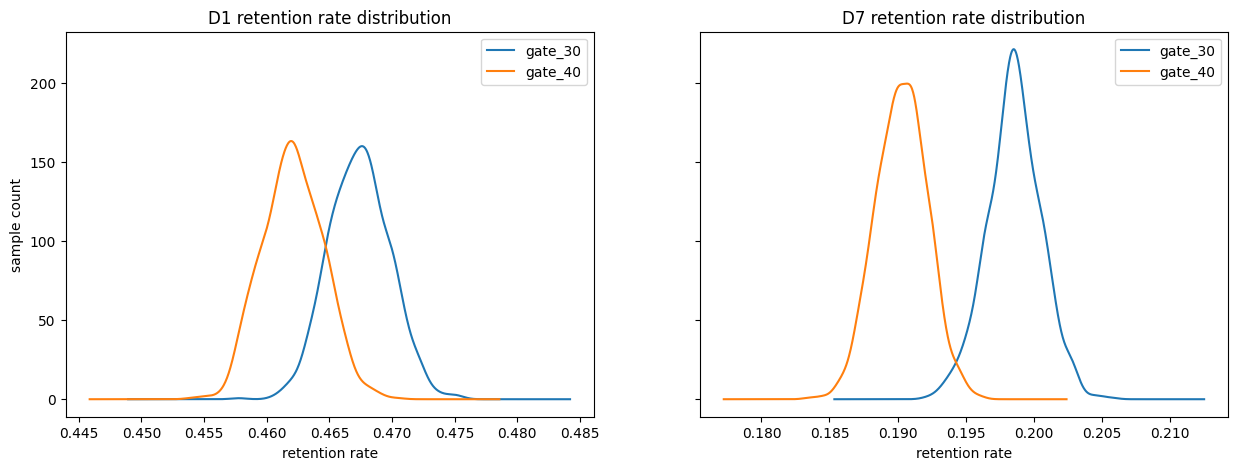

In [15]:
# 부트스트랩 결과 retention 분포 확인
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(15, 5))

d1_boot.plot.kde(ax=ax1)
ax1.set_xlabel("retention rate")
ax1.set_ylabel("sample count")
ax1.set_title("D1 retention rate distribution")

d7_boot.plot.kde(ax=ax2)
ax2.set_xlabel("retention rate")
ax2.set_ylabel("sample count")
ax2.set_title("D7 retention rate distribution")

plt.show()

해당 분포 그래프를 통해 부트스트래핑을 통한 retention 결과가 얼마나 불확실성을 갖는지 확인할 수 있습니다. 그래프 상으로는 gate 40 그룹의 retention 수치가 높지만 해당 차이가 실질적인 의미를 갖는지 알아보겠습니다.

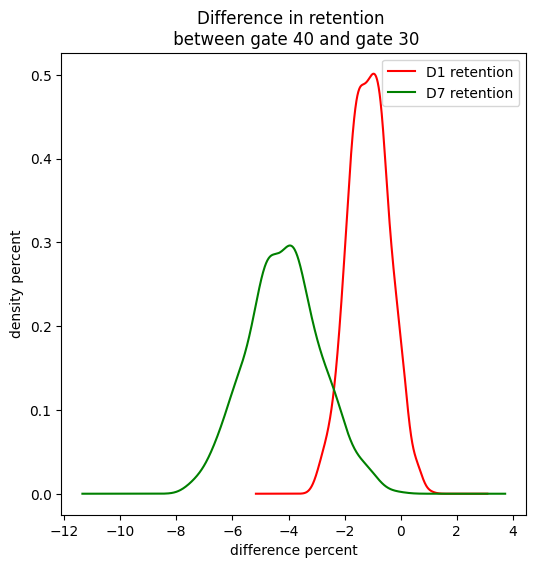

In [ ]:
# 리텐션 차이 계산 : 변경된 게이트의 retention이 기존 대비 얼마나 변했는가? (상대)
d1_boot['diff'] = ((d1_boot['gate_40'] - d1_boot['gate_30']) / d1_boot['gate_30'] * 100)
d7_boot['diff'] = ((d7_boot['gate_40'] - d7_boot['gate_30']) / d7_boot['gate_30'] * 100)

fig, ax1 = plt.subplots(1, 1, figsize=(6,6))

d1_boot['diff'].plot.kde(ax=ax1, label="D1 retention", c="red")
d7_boot['diff'].plot.kde(ax=ax1, label="D7 retention", c='green')
ax1.set_xlabel("difference percent")
ax1.set_ylabel("density percent")
ax1.set_title("Difference in retention \n between gate 40 and gate 30")
plt.legend()
plt.show()

In [17]:
# 0 이하 데이터의 비율
prob_1 = (d1_boot['diff'] < 0).sum() / len(d1_boot['diff'])
prob_7 = (d7_boot['diff'] < 0).sum() / len(d7_boot['diff'])

print(f"gate 40의 D1 리텐션이 gate 30보다 낮은 확률 : {round(prob_1, 2)* 100} % \
\ngate 40의 D7 리텐션이 gate 30보다 낮을 확률 : {round(prob_7, 2)* 100} %")

gate 40의 D1 리텐션이 gate 30보다 낮은 확률 : 94.0 % 
gate 40의 D7 리텐션이 gate 30보다 낮을 확률 : 100.0 %


In [27]:
np.percentile(d1_boot['diff'], [2.5, 97.5])

array([-2.5334592 ,  0.20523473])

In [28]:
np.percentile(d7_boot['diff'], [2.5, 97.5])

array([-6.66169962, -1.45808797])

해당 그래프를 통해 gate 40의 D1 retention은 gate 30 대비 상대적으로 1 ~ 2% 낮았으며, D7 retention의 경우 3 ~ 5% 낮다는 것을 알 수 있습니다.    
또한 gate40의 retention이 gate30 대비 낮을 확률은 94%, 100%로 나타났습니다.

---
# 추가 분석
두 그룹의 sum_gamerounds는 어떤 차이가 있을지 확인해 봅시다.

In [20]:
# retention 계산 함수
sum_30 = []
sum_40 = []

# 실험군 대조군 비율 유지
gate_30 = df[df['version'] == 'gate_30']
gate_40 = df[df['version'] == 'gate_40']

np.random.seed(42)

# 복원추출 retention 계산 1000번 
for _ in range(1000):
    sum_30.append(gate_30.sample(frac=1, replace=True)['sum_gamerounds'].median())
    sum_40.append(gate_40.sample(frac=1, replace=True)['sum_gamerounds'].median())


sum_boot = pd.DataFrame({'gate_30' : sum_30, 'gate_40' : sum_40})
sum_boot

,gate_30,gate_40
0,18.0,18.0
1,18.0,18.0
2,19.0,18.0
3,18.0,18.0
4,19.0,18.0
...,...,...
995,18.0,18.0
996,18.0,18.0
997,18.0,18.0
998,18.0,18.0


In [21]:
print(sum_boot['gate_30'].mean())
print(sum_boot['gate_40'].mean())

18.196
17.9595


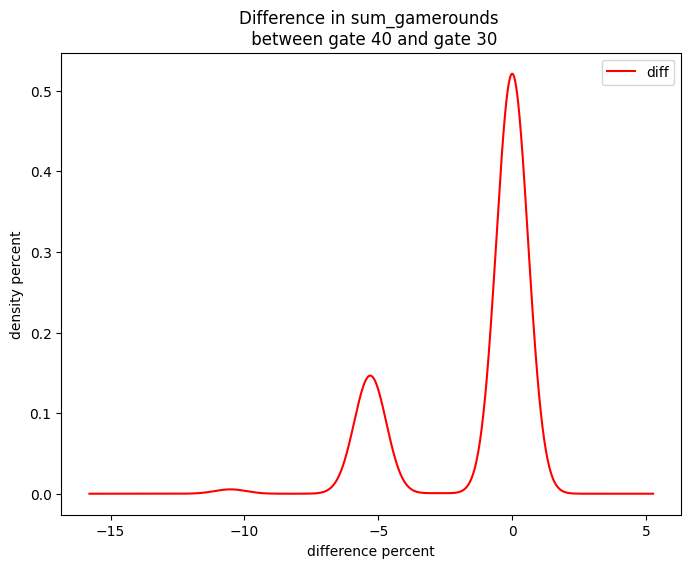

In [30]:
sum_boot['diff'] = ((sum_boot['gate_40'] - sum_boot['gate_30']) / sum_boot['gate_30'] * 100)

fig, ax1 = plt.subplots(figsize=(8,6))

sum_boot['diff'].plot.kde(ax=ax1, c="red")
ax1.set_xlabel("difference percent")
ax1.set_ylabel("density percent")
ax1.set_title("Difference in sum_gamerounds \n between gate 40 and gate 30")
plt.legend()
plt.show()

In [23]:
prob_sum0 = (sum_boot['diff'] < 0).sum() / len(sum_boot['diff'])
prob_sum1 = (sum_boot['diff'] == 0).sum() / len(sum_boot['diff'])
prob_sum2 = (sum_boot['diff'] > 0).sum() / len(sum_boot['diff'])

print(f' gate_40의 sum_gamerounds가 gate_30 대비 낮을 확률 : {round(prob_sum0, 2)* 100}%')
print(f' gate_40의 sum_gamerounds가 gate_30 과 같을 확률 : {round(prob_sum1, 2)* 100}%')
print(f' gate_40의 sum_gamerounds가 gate_30 대비 높을 확률 : {round(prob_sum2, 2)* 100}%')

 gate_40의 sum_gamerounds가 gate_30 대비 낮을 확률 : 23.0%
 gate_40의 sum_gamerounds가 gate_30 과 같을 확률 : 77.0%
 gate_40의 sum_gamerounds가 gate_30 대비 높을 확률 : 0.0%


77%의 확률로 동일한 sum_gamerounds 중앙값을 갖는다는 것을 통해 gate 이동이 sum_gamerounds에 뚜렷한 차이를 준다고 할 수 없다는 것을 알 수 있었습니다.